# TAREA 1 SAMUEL ALEJANDRO DURÁN ENRÍQUEZ 

### No se hace parte extra

In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import nltk
import time

## 2 Vistazo a los datos

1. Cargue todas las conferencias en un string y aplique la función split para generar tokens
fácilmente.

In [2]:
#Leer todas las conferencias y guardarlas en un string muy largo
conferencias_total= ""
for f_pagina in glob.glob("./estenograficas_limpias_por_fecha/*"):
    with open(f_pagina, "r", encoding="utf-8") as file:
        conferencias_total += file.read()

2. Contar la cantidad de palabras en todas las conferencias

In [3]:
conferencias_total_split= conferencias_total.split()
print("Cantidad de palabras en todas las mañaneras:", len(conferencias_total_split))

Cantidad de palabras en todas las mañaneras: 14787266


3. Extraer el vocabulario y mostrar su longitud de todo el corpus.


In [4]:
#Buscamos extraer las palabras unicas para saber la longitud del vocabulario.
conferencias_total_vocabulario=set(conferencias_total_split)
long_vocabulario=len(conferencias_total_vocabulario)
print("Longitud del vocabulario", (long_vocabulario))

Longitud del vocabulario 242145


4. Mida la riqueza del vocabulario de alguna forma en todos los documentos.


Promedio de riqueza 3.148559930109096


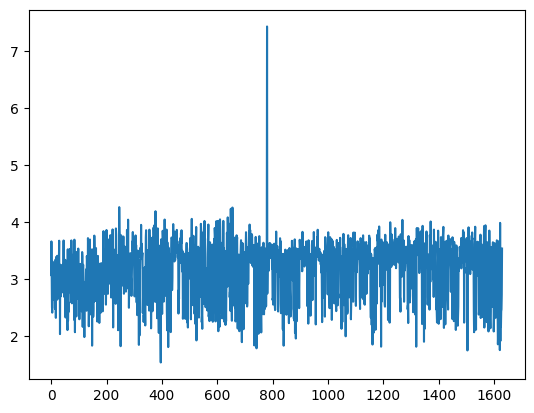

In [5]:
#medir la riqueza requiere saber cuantas palabras del total se usan
riqueza_vocabulario= []

for f_pagina in glob.glob("./estenograficas_limpias_por_fecha/*"):
    with open(f_pagina, "r", encoding="utf-8") as file:
        texto=file.read()
        palabras = texto.split()
        #print(len(palabras))
        #Se calcula la riqueza sobre un mismo documento
        riqueza = len(palabras) / len(set(palabras))
        #"Resultado indica que cada palabra es empleada un cierto numero de veces por el autor"
        riqueza_vocabulario.append(riqueza)

plt.plot(riqueza_vocabulario)
print("Promedio de riqueza", np.mean(riqueza_vocabulario))

5. Haga lo mismo que los 4 puntos anteriores pero con todo el texto en min´usculas. Vea
las diferencias y comente brevemente (sino comentas habr´a penalizaci´on).

Cantidad de palabras en todas las mañaneras: 14787266
Longitud del vocabulario 222029
Promedio de riqueza 3.336112800123406


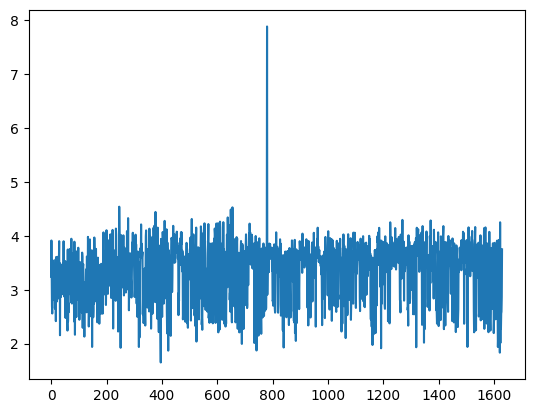

In [6]:
conferencias_total_minuscula=conferencias_total.lower()

conferencias_total_minuscula_split= conferencias_total_minuscula.split()
print("Cantidad de palabras en todas las mañaneras:", len(conferencias_total_minuscula_split))

conferencias_total_minuscula_vocabulario=set(conferencias_total_minuscula_split)
print("Longitud del vocabulario", len(conferencias_total_minuscula_vocabulario))


riqueza_vocabulario_minuscula= []

for f_pagina in glob.glob("./estenograficas_limpias_por_fecha/*"):
    with open(f_pagina, "r", encoding="utf-8") as file:
        texto=file.read()
        texto = texto.lower()
        palabras = texto.split()
        #print(len(palabras))
        #Se calcula la riqueza sobre un mismo documento
        riqueza = len(palabras) / len(set(palabras))
        #"Resultado indica que cada palabra es empleada un cierto numero de veces por el autor"
        riqueza_vocabulario_minuscula.append(riqueza)

plt.plot(riqueza_vocabulario_minuscula)
print("Promedio de riqueza", np.mean(riqueza_vocabulario_minuscula))


Al contar las minusculas sigue existiendo la misma cantidad de palabras totales pero disminuyen las ocurrencias de palabras unicas. Entonces en el primer caso se estaban contando las palabras con mayuscula diferentes de las minusculas aun cuando tuvieran las mismas letras. Esto se ve al bajar la cantidad del vocabulario de 242,145 a 222,029. La riqueza de palabras en los documentos también aumenta ligeramente de 3.15 a 3.33.

6. Haga lo mismo que los puntos 1, 2 y 3 usando el tokenizador RegExp de NLTK, con
una expresi´on regular que trate de sacar solo tokens que pueden contener solo letras
may´usculas y min´usculas. Despu´es cargue los tokens en un objeto Text de NLTK en
lugar de una lista de Python.


In [7]:
#Crear un tokenizer con una expresion que saque solo palabras

tokenizer = nltk.RegexpTokenizer(r'\b[a-zA-Z]+\b')
#Usar el tokenizer construido para nuestro texto total
conferencias_total_token= tokenizer.tokenize(conferencias_total)
#Guardarlo asi hace una lista pero queremos guardarlo en un objeto especial con mas funciones
conferencias_total_token = nltk.Text(conferencias_total_token)

print("Cantidad de palabras en todas las mañaneras",len(conferencias_total_token))

print("Longitud del vocabulario",len(set(conferencias_total_token)))



Cantidad de palabras en todas las mañaneras 12870031
Longitud del vocabulario 79386


In [8]:
conferencias_total_token_minusculas=tokenizer.tokenize(conferencias_total_minuscula)
 
 #La buena es con el diccionario en minusculas, sobreescribimos en la misma variables
conferencias_total_token = nltk.Text(conferencias_total_token_minusculas)

print("Cantidad de palabras en todas las mañaneras",len(conferencias_total_token))

print("Longitud del vocabulario",len(set(conferencias_total_token)))

#Ahora con tokenizador tweet tokenizer en lugar del tokenizer regexp

tweet_tokenizer=nltk.TweetTokenizer()

conferencias_total_tweet_token= tweet_tokenizer.tokenize(conferencias_total_minuscula)

print("Cantidad de palabras en todas las  (tweet)",len(conferencias_total_tweet_token))

print("Longitud del vocabulario (tweet)",len(set(conferencias_total_tweet_token)))



Cantidad de palabras en todas las mañaneras 12870031
Longitud del vocabulario 68178
Cantidad de palabras en todas las  (tweet) 17220239
Longitud del vocabulario (tweet) 93066


Se obtienen más palabras y tokens con Tweettokenizer. Esto se debe a que ya no solo se conservan las palabras, se incluyen terminos que tienen más simbolos. Investigando es porque Tweet tokenizer utiliza hastags, emojis, abreviaciones, urls entre otros.

## Funciones NLTK

1. Use la función concordance para ver el contexto de 5 palabras que usted elija

In [9]:
conferencias_total_tweet_token= nltk.Text(conferencias_total_tweet_token)

In [12]:
#La funcino concordance pero a partir de conferencias total tweet tokenizer
print("Ver contexto de 5 palabras elegidas con concordance")
print("PALABRA ESTRELLA")
conferencias_total_tweet_token.concordance("estrella")

Ver contexto de 5 palabras elegidas con concordance
PALABRA ESTRELLA
Displaying 25 of 44 matches:
psulados , dice la diputada nohemí estrella , que es la que encabeza una organ
que tienen precios altos y con una estrella los que tienen los precios más eco
os . el vochito , ahí está nuestra estrella de la subasta , ahí lo pueden ver 
ían a garcía luna , era el policía estrella , asociaciones civiles , conservad
n que tocar con la diputada nohemí estrella , hay que tocar antes de llegar a 
 usted en el destino , en la buena estrella ? ¿ con qué cosas complementa su g
jalostotitlán , jalisco ; servicio estrella del sur , en villa de álvarez , co
ntos , la heráldica , la cruz , la estrella y demás , hizo un gran trabajo . e
e hecho , ni permisos tienen : gas estrella en acapulco , guerrero ; preciso g
esinato de jessica silva , jessica estrella silva , no sé si usted ya tenga in
los es una diputada local , nohemí estrella leal , y hace y deshace en el esta
televisora donde está de conducto

In [15]:
print("PALABRA MOLE")
conferencias_total_tweet_token.concordance("mole")

PALABRA MOLE
Displaying 19 of 19 matches:
an bots , ahí están , a darle que es mole de olla . ‘ este es el momento , ya 
l pueblo : ‘ si hay plumas , huele a mole después ’ . nosotros nos vamos a hac
xicana , pues vamos a darle , que es mole de olla . presidente andrés manuel l
a , y el mezcal y los mariachis , el mole , y el maíz y el chocolate . y españ
, en el caso de la comida poblana el mole , el mole , pero hay muchísimos otro
so de la comida poblana el mole , el mole , pero hay muchísimos otros platillo
 conoce , por ejemplo , el suculento mole de cadera de tehuacán , y tiene su h
lo más importante de brasil . lo del mole de cadera es parecido . en las famos
os para los peones y de ahí surge el mole de cadera , que es exquisito . en mi
o ahora que está , acaba de pasar el mole de cadera , fue un trabajo , porque 
dico en nuevo león , está en su mero mole defendiendo el conservadurismo , por
ga la familia , se hacía la comida , mole y todas las comidas o todos los plat
an tan bue

In [17]:
print("PALABRA CIMAT")
conferencias_total_tweet_token.concordance("cimat")

PALABRA CIMAT
Displaying 6 of 6 matches:
 . los menciono por institución : el cimat , el centro de investigación en mate
cos , el segundo grupo académico del cimat además tiene una colaboración con el
és christen y marcos capistrán , del cimat , del propio centro de investigación
y talentoso grupo de matemáticos del cimat y del instituto de matemáticas de la
icas recrea , en el que participa el cimat , el centro de investigación en mate
n educativa en una escuela de nombre cimat si no pagan la cuota , sin importarl


In [19]:
print("PALABRA PROCESADOR")
conferencias_total_tweet_token.concordance("procesador")

PALABRA PROCESADOR
Displaying 7 of 7 matches:
taje de la estructura de acero en procesador central y salas de última espera 
taje de la estructura de acero en procesador central y salas de última espera 
taje de la estructura de acero en procesador central y salas de última espera 
 de 16 pulgadas desde el complejo procesador de cactus hacia dos bocas . actua
asoducto proveniente del complejo procesador cactus y en el acueducto continúa
a empresa construyera un complejo procesador , una planta en un complejo proce
sador , una planta en un complejo procesador de burgos de pemex . este contrat


In [20]:
print("PALABRA FBI")
conferencias_total_tweet_token.concordance("FBI")

PALABRA FBI
Displaying 25 of 67 matches:
vestigaciones , lo que se conoce como fbi . apenas ayer di a conocer que había 
ue se está realizando , sobre todo el fbi allá . gracias . presidente andrés ma
gación , porque decía el director del fbi , en una comparecencia reciente - que
 unidos . eso lo dijo el director del fbi ante el congreso . y por esa razón , 
 . lo describe el propio director del fbi y con mucho gusto les puedo compartir
e estos datos que habría analizado el fbi . alejandro encinas rodríguez : se es
 había solicitado la intervención del fbi para poder intervenir en este caso , 
podrían ustedes trabajar junto con el fbi o de plano esto no podría ? president
quien determine si recibirá ayuda del fbi . en ese contexto , queremos saber si
de permitir el ingreso de agentes del fbi a territorio mexicano . si tiene la c
más detalles de cuántos elementos del fbi , en qué condiciones estarían laboran
aduría general de la república , y el fbi para casos específicos , mismo que ha

2. Elija una palabra que le parezca interesante y muestre palabras con uso similar. Muestre
tambi´en los contextos comunes. COMENTE al respecto.

In [21]:
conferencias_total_tweet_token.similar("ganso")

presidente país mundo problema pueblo bienestar gobierno estado
momento universal futuro ejército fentanilo territorio agua sureste
salvador conservadurismo imss diálogo


In [22]:
print("PALABRA GANSO")
conferencias_total_tweet_token.concordance("GANSO")


PALABRA GANSO
Displaying 25 of 205 matches:
 va a acabar la impunidad . me canso ganso . y vamos todos a resolver los probl
 va a acabar la impunidad . me canso ganso . ahí está el ejemplo , la refinería
va a acabar la corrupción . me canso ganso . pero aquí hay la virtud de la hone
sí como lo vengo diciendo : me canso ganso . va porque va . y lo vamos a hacer 
éxico y , como dijo usted , me canso ganso para que todas las constructoras ten
va a acabar la corrupción . me canso ganso . yo estoy , por eso , muy contento 
 esto va ’ , es porque va . me canso ganso . ¿ por qué le ponen dos años ? porq
a acabar con la impunidad , me canso ganso . el problema de méxico no es la fal
ién se cansa primero . pero me canso ganso de que vamos a poner orden . imagíne
todo eso se va a terminar , me canso ganso . claro que hay reacciones , porque 
a a acabar la impunidad . me canso , ganso . ¿ y qué vamos a ganar con eso ? mu
 va a acabar la impunidad . me canso ganso . me dio mucho gusto estar con us

Las palabras con uso similar a ganso son completamente diferentes al significado de esta palabra. Pero probablemente se deba a como lo usaba en situaciones de hartazgo. Siendo así, muchas cosas causaban hartazgo y de ahí que pueda ser tan extenso las palabras similares.

3. Haciendo uso de alguna librer´ıa time de Python: organice todos los archivos de las
conferencias desde la m´as antigua hasta la m´as nueva (echando mano del nombre del
archivo y fechas), y c´arguelos en un objeto Text para generar un dispersion plot de las
siguientes palabras: prian, corrupci´on, mafia, narco, gasolina, pipas, conacyt, conahcyt,
ciencia, turismo, pandemia, coronavirus, covid, delta, omicron, vacuna, vacunacion y
otras cinco palabras de su elecci´on.


In [2]:
#Es necesario sacar los nombres de los archivos, sortearlos y luego ya guardarlos en una lista
#El procedimiento se limita en numero de archivos por tiempo de ejecución.

fecha_archivos = glob.glob("./estenograficas_limpias_por_fecha/*")
fecha_archivos = sorted(fecha_archivos)
fecha_archivos = fecha_archivos[:1000]

In [4]:
tweet_tokenizer=nltk.TweetTokenizer()

In [13]:
conferencias_ordenadas= ""
for f_pagina in fecha_archivos:
    with open(f_pagina, "r", encoding="utf-8") as file:
        conferencias_ordenadas += file.read()
        
conferencias_ordenadas= conferencias_ordenadas.lower()

conferencias_ordenadas_token =tweet_tokenizer.tokenize(conferencias_ordenadas)

conferencias_ordenadas_token = nltk.Text(conferencias_ordenadas_token)


<Figure size 1200x500 with 0 Axes>

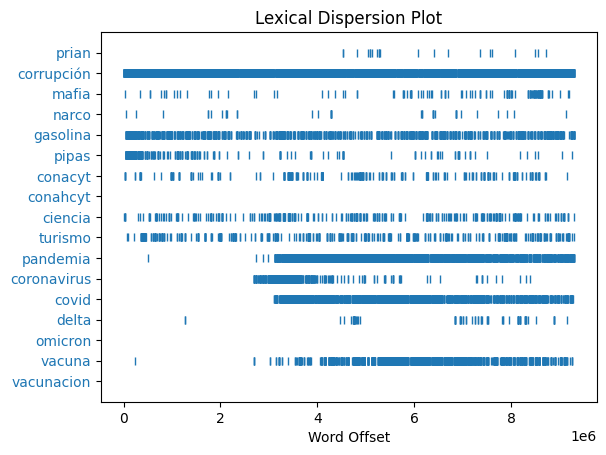

In [34]:
palabras_clave = ["prian", "corrupción", "mafia", "narco", "gasolina", "pipas",
                  "conacyt", "conahcyt", "ciencia", "turismo", "pandemia", "coronavirus",
                  "covid", "delta", "omicron", "vacuna", "vacunacion"]

# Generar el dispersion plot
plt.figure(figsize=(12, 5))  # Ajustar tamaño del gráfico
conferencias_ordenadas_token.dispersion_plot(palabras_clave)
plt.show()


<Figure size 1200x500 with 0 Axes>

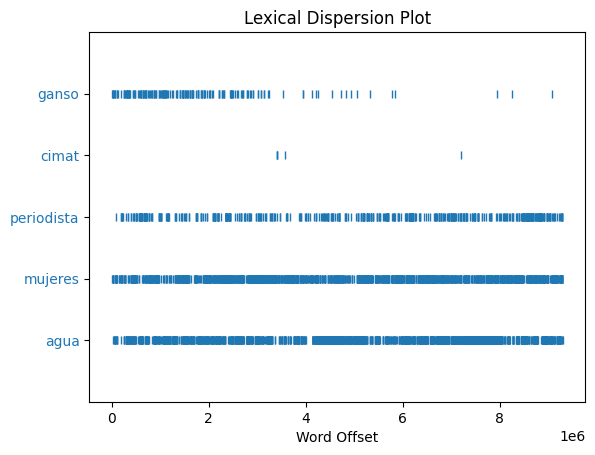

In [38]:
palabras_clave_elegidas = ["ganso","cimat","periodista","mujeres","agua"]

# Generar el dispersion plot
plt.figure(figsize=(12, 5))  # Ajustar tamaño del gráfico
conferencias_ordenadas_token.dispersion_plot(palabras_clave_elegidas)
plt.show()

4. Muestre 50 colocaciones de todo el corpus.

In [41]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\disom\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [43]:
conferencias_ordenadas_token.collocations(num=50)

lópez obrador; andrés manuel; manuel lópez; presidente andrés; versión
estenográfica; por ciento; estados unidos; buenos días; todos los;
señor presidente; prensa matutina; nada más; por eso; guardia
nacional; muchas gracias; desde luego; adultos mayores; último grito;
mil millones; redes sociales; por ejemplo; muy importante; cuarta
transformación; todas las; baja california; derechos humanos; sin
embargo; marcelo ebrard; nuestro país; sobre todo; quintana roo; que
que; creo que; por qué; para que; #amlo #gritodeindependencia;
#últimogrito #amlo; argument supplied; close copyright;
documentosdocumentos gabinetegabinete; invalid argument; reserved
developed; rights reserved; threads spotify; spotify telegram;
telegram tiktok; biografía search; boletines transcripciones; tiktok
whatsapp; youtube threads


5. Muestre un histograma de longitud en caracteres de las palabras. Muestre en el histograma el top 5 de longitudes m´as largas.

longitudes más largas [39, 41, 42, 43, 68]


(array([1.711495e+06, 1.966247e+06, 1.271048e+06, 6.384430e+05,
        8.021800e+05, 6.618710e+05, 6.626090e+05, 5.357830e+05,
        3.343440e+05, 3.193230e+05, 1.650090e+05, 1.009880e+05,
        6.749400e+04, 3.251600e+04, 1.759300e+04, 5.886000e+03,
        1.140000e+03, 3.576000e+03]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.]),
 <BarContainer object of 18 artists>)

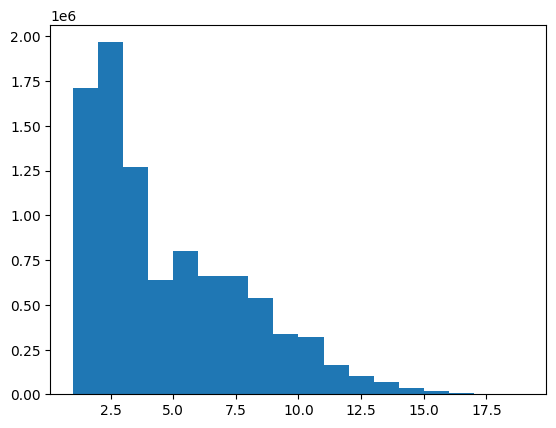

In [53]:
#Obtener longitud de cada palabra para hacer historgrama

longitud= []
for palabra in conferencias_ordenadas_token:
    long= len(palabra)
    longitud.append(long)

# Crear el histograma con plot
longitud_larga= sorted(set(longitud))[-5:]
print("longitudes más largas", longitud_larga)
plt.hist(longitud, bins=range(1, 20))


In [57]:
#Encontrar cuales son las palabras más largas
#encontrar la frecuencia de palabras
fdist=nltk.FreqDist(conferencias_ordenadas_token)
#Todo en un solo renglón:
lista_50=sorted(set([ w for w in conferencias_ordenadas_token if len(w)>= 8 and fdist[w] >5 ])) [:50]
lista_50

['#covid19',
 '#gritodeindependencia',
 '#narcopresidenteamlo',
 '#quédateencasa',
 '#últimogrito',
 '2012-2018',
 '2018-2024',
 '2019-2020',
 '2019-2024',
 '2020-2021',
 '@presidenteamlo_',
 'abajofirmantes',
 'abanderamiento',
 'abandona',
 'abandonada',
 'abandonadas',
 'abandonado',
 'abandonados',
 'abandonan',
 'abandonando',
 'abandonar',
 'abandonaron',
 'abandone',
 'abandonen',
 'abandono',
 'abandonó',
 'abaratar',
 'abarcando',
 'abarroteros',
 'abarrotes',
 'abastece',
 'abastecen',
 'abastecer',
 'abastecerse',
 'abasteciendo',
 'abastecimiento',
 'abastecimientos',
 'abastecía',
 'abastecían',
 'abatimiento',
 'aberración',
 'abiertamente',
 'abiertas',
 'abiertos',
 'abogadas',
 'abogados',
 'abolición',
 'abonando',
 'abordado',
 'abordaje']

7. Ver https://www.nltk.org/book/ch02.html en la secci´on 1.5. Proponga una gr´afica
usando ConditionalFreqDist como la de la Secci´on 1.5 para estos datos. Usted elige las
palabras.


In [20]:
#Usar condfreqdist para hacer una grafica
# Que tan seguido se usa una palabra con base en la longitud de esa palabra

cfdist = nltk.ConditionalFreqDist((len(word), word) for word in conferencias_ordenadas_token)

In [40]:
longitudes = list(range(3, 21))  # De longitud de palabra entre 1 y 15

for length in longitudes:
    if length in cfdist:
        print(f"Palabra de {length} caracteres (unicas y ocuurrencias)", cfdist[length])


Palabra de 3 caracteres (unicas y ocuurrencias) <FreqDist with 1789 samples and 1271048 outcomes>
Palabra de 4 caracteres (unicas y ocuurrencias) <FreqDist with 3015 samples and 638443 outcomes>
Palabra de 5 caracteres (unicas y ocuurrencias) <FreqDist with 5444 samples and 802180 outcomes>
Palabra de 6 caracteres (unicas y ocuurrencias) <FreqDist with 6129 samples and 661871 outcomes>
Palabra de 7 caracteres (unicas y ocuurrencias) <FreqDist with 8545 samples and 662609 outcomes>
Palabra de 8 caracteres (unicas y ocuurrencias) <FreqDist with 9730 samples and 535783 outcomes>
Palabra de 9 caracteres (unicas y ocuurrencias) <FreqDist with 9611 samples and 334344 outcomes>
Palabra de 10 caracteres (unicas y ocuurrencias) <FreqDist with 8793 samples and 319323 outcomes>
Palabra de 11 caracteres (unicas y ocuurrencias) <FreqDist with 6613 samples and 165009 outcomes>
Palabra de 12 caracteres (unicas y ocuurrencias) <FreqDist with 4239 samples and 100988 outcomes>
Palabra de 13 caracteres (

8. Use la lista de stopwords de nltk y obtenga la cantidad de palabras en los datos con y
sin stopword. Comente brevemente las diferencias.

In [31]:
#quitamos signos de puntuación, meten ruido más adelante
import string
base= [word for word in conferencias_ordenadas_token if word not in string.punctuation]

palabras_con_sw= len(base)

# Obtener la lista de stopwords en inglés
stop_words = set(nltk.corpus.stopwords.words('spanish'))

palabras_sin_sw= [word for word in base if word not in stop_words]

print("Longitud de diccionario con stopwords",palabras_con_sw)
print("Longitud de diccionario SIN stopwords",len(palabras_sin_sw))


Longitud de diccionario con stopwords 8120118
Longitud de diccionario SIN stopwords 4018344


Quitar las stopwords reduce significativamente el numero de palabras totales. Es necesario remover los signos de puntuación de otra manera aparecen como palabras más frecuentes.

9. Muestre las 300 palabras m´as frecuentes en las conferencias, sin tomar en cuenta stopwords. Mu´estrelas de la m´as frecuente a la menos frecuente.

In [33]:
fdist = nltk.FreqDist(palabras_sin_sw)
palabras_300_frecuentes= fdist.most_common(300)

print("Palabras frecuentas")
palabras_300_frecuentes

Palabras frecuentas


[('presidente', 48653),
 ('¿', 34748),
 ('si', 27574),
 ('vamos', 26865),
 ('va', 26791),
 ('lópez', 25565),
 ('manuel', 25195),
 ('obrador', 24892),
 ('andrés', 24700),
 ('entonces', 23926),
 ('mil', 23920),
 ('méxico', 22981),
 ('aquí', 17786),
 ('gobierno', 16466),
 ('ahora', 14014),
 ('dos', 12720),
 ('país', 11865),
 ('pueblo', 11816),
 ('ver', 11684),
 ('millones', 11599),
 ('van', 11500),
 ('pesos', 11157),
 ('caso', 10863),
 ('pues', 10423),
 ('ahí', 10360),
 ('ser', 10328),
 ('cómo', 10298),
 ('nacional', 10134),
 ('así', 9955),
 ('‘', 9898),
 ('hacer', 9897),
 ('días', 9787),
 ('bueno', 9769),
 ('pregunta', 9661),
 ('gente', 9601),
 ('’', 9349),
 ('salud', 9182),
 ('año', 8819),
 ('gracias', 8656),
 ('prensa', 8637),
 ('usted', 8620),
 ('señor', 8517),
 ('ciento', 8471),
 ('tener', 8416),
 ('bien', 8379),
 ('manera', 8136),
 ('años', 8099),
 ('importante', 8087),
 ('tres', 7971),
 ('…', 7961),
 ('decir', 7917),
 ('mismo', 7840),
 ('puede', 7768),
 ('todas', 7739),
 ('tema', 7

## 4 Otras librerıas en Python (20pts)


Investigue y comente brevemente en sus propias palabras:
1. Mencione dos librerıas en Python adem´as de NLTK para NLP. Ponga una desventaja
y ventaja de cada una.


A) Spacy
Tiene funciones similares a NLTK y es su principal competidor. Esta diseñada para funcionar rapidamente con mucha información y poca memoria y ofrece el analizador sintactico más rápido del mercado. Tiene la desventaja de soportar solamente 7 idiomas.

B) textBlob
Es una función de introducción para NLP, ofrece una interfaz más sencilla y realiza funcinoes similares a NLTK. Tiene la desventaja de ser lenta, similar a NLTK.



2. Mencione tres alternativas para Text Processing en NLP qu´e existen en otros lenguajes.
De una ventaja y desventaja de cada una.

A) en Java esta OpenNLP: tiene la ventaja de integrarse con aplicaciones empresariales en Java y ofrece una gran variedad de modelos preentrenados para varias tareas de NLP. Tiene la desventaja de tener un desarrollo lento. No todo está documentado en los ejemplos y los modelos preentrenados podrian requerir más entrenamiento.

B) Stanford coreNLP para Java
Librería desarrollada en Stanford. Es exacta para NLP y provee anotaciones linguisticas complejas. Su mayor ventaja con respecto a NLTK funcinoa a alta velocidad y es buena en un ambiente completo de desarrollo. Es conocida por ser robusta, incluyendo reconocimiento de nombres de entidades y resolució de coreferencias. Algunos componentes se pueden integrar con NLTK. 

C) Quanteda para R

Quanteda ofrece un paquete completo de flujo de trabajo para NLP. Es m+as rapida que otros paquetes de R y python, y funcinoa bien con grandes cantidades de texto. Tiene la desventaja que está limitado a R y puede limitarse cuando el entorno es dominante en otro lenguaje. No tiene tanta variedad de modelos preentenados.
